# Random Forest

Approach: flatten each (30, 126) sequence into a feature vector of summary statistics over time, then train a Random Forest model

Evaluation: 5 Kfold for tuning hyperparamters, then testing with the held out data.

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

DATA_DIR = r'D:\MLproject\code\processed_data_New1'
RANDOM_SEED = 80

In [2]:
# load data
dev  = np.load(os.path.join(DATA_DIR, 'dev.npz'))
test = np.load(os.path.join(DATA_DIR, 'test.npz'))
folds = np.load(os.path.join(DATA_DIR, 'cv_folds.npz'))
classes = np.load(os.path.join(DATA_DIR, 'classes.npy'), allow_pickle=True)

X_dev, y_dev, groups_dev = dev['X'], dev['y'], dev['groups']
X_test, y_test = test['X'], test['y']

print(f'Dev:  {X_dev.shape}, {len(np.unique(groups_dev))} participants')
print(f'Test: {X_test.shape}')
print(f'Classes: {len(classes)}')
print(f'Random chance: {100/len(classes):.1f}%')

Dev:  (16007, 30, 274), 18 participants
Test: (2841, 30, 274)
Classes: 50
Random chance: 2.0%


In [4]:
#summarizing the (30,126) into a signle feature vecotr for the random forest
numPos = 137

def extract_rf_features(X):
    # position stats across time
    pos = X[:, :, :numPos]  
    vel = X[:, :, numPos:]  

    # position stats across time
    f_mean = pos.mean(axis=1)
    f_std = pos.std(axis=1)
    f_min = pos.min(axis=1)
    f_max = pos.max(axis=1)
    f_range = f_max - f_min
    f_disp = pos[:, -1, :] - pos[:, 0, :] 

    # velocity stats
    v_mean = vel.mean(axis=1)
    v_std = vel.std(axis=1)
    v_absmax = np.abs(vel).max(axis=1)  

    return np.concatenate([f_mean, f_std, f_min, f_max, f_range, f_disp, v_mean, v_std, v_absmax], axis=1)
X_dev_rf  = extract_rf_features(X_dev)
X_test_rf = extract_rf_features(X_test)
print(f'Dev feature matrix:  {X_dev_rf.shape}')
print(f'Test feature matrix: {X_test_rf.shape}')

Dev feature matrix:  (16007, 1233)
Test feature matrix: (2841, 1233)


In [5]:
# 5 folds to do cross validation
n_folds = 5
fold_accs = []

for fold in range(n_folds):
    tr = folds[f'fold_{fold}_train']
    va = folds[f'fold_{fold}_val']
    # base RF for each fold 
    rf = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_split=2, n_jobs=-1, random_state=RANDOM_SEED,)
    rf.fit(X_dev_rf[tr], y_dev[tr])
    acc = rf.score(X_dev_rf[va], y_dev[va])
    fold_accs.append(acc)
    print(f'Fold {fold+1}: {acc*100:.2f}%')

print(f'\nMean CV accuracy: {np.mean(fold_accs)*100:.2f}% ± {np.std(fold_accs)*100:.2f}%')

Fold 1: 39.37%
Fold 2: 31.01%
Fold 3: 33.16%
Fold 4: 52.95%
Fold 5: 23.63%

Mean CV accuracy: 36.02% ± 9.84%


In [6]:
# hyperparamater tuning... testing a ton of different things.

param_grid = [
    {'n_estimators': 200, 'max_depth': None, 'max_features': 'sqrt'},
    {'n_estimators':400, 'max_depth': None, 'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_depth': None, 'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_depth': 40,   'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_features': 0.3, 'min_samples_leaf': 1},
    {'n_estimators': 500, 'max_depth': None, 'max_features': 'log2'},
    {'n_estimators': 800, 'max_depth': None, 'max_features': 'sqrt'},
]

results = []
for params in param_grid:
    accs = []
    for fold in range(n_folds):
        tr = folds[f'fold_{fold}_train']
        va = folds[f'fold_{fold}_val']
        rf = RandomForestClassifier(
            **params, n_jobs=-1, random_state=RANDOM_SEED,
        )
        rf.fit(X_dev_rf[tr], y_dev[tr])
        accs.append(rf.score(X_dev_rf[va], y_dev[va]))
    mean_acc = np.mean(accs)
    results.append((params, mean_acc, np.std(accs)))
    print(f'{params}: {mean_acc*100:.2f}% ± {np.std(accs)*100:.2f}%')

best_params, best_acc, _ = max(results, key=lambda r: r[1])
print(f'\nBest: {best_params} @ {best_acc*100:.2f}%')

{'n_estimators': 200, 'max_depth': None, 'max_features': 'sqrt'}: 35.75% ± 9.73%
{'n_estimators': 400, 'max_depth': None, 'max_features': 'sqrt'}: 36.25% ± 9.96%
{'n_estimators': 500, 'max_depth': None, 'max_features': 'sqrt'}: 36.20% ± 9.94%
{'n_estimators': 500, 'max_depth': 40, 'max_features': 'sqrt'}: 36.12% ± 9.56%
{'n_estimators': 500, 'max_features': 0.3, 'min_samples_leaf': 1}: 37.11% ± 10.13%
{'n_estimators': 500, 'max_depth': None, 'max_features': 'log2'}: 33.57% ± 9.51%
{'n_estimators': 800, 'max_depth': None, 'max_features': 'sqrt'}: 36.44% ± 9.77%

Best: {'n_estimators': 500, 'max_features': 0.3, 'min_samples_leaf': 1} @ 37.11%


In [7]:
# ── Final model: train on full dev set with best params, evaluate on test ─────
# Test set participants have NEVER been seen. This is the number you report.

final_rf = RandomForestClassifier(
    **best_params, n_jobs=-1, random_state=RANDOM_SEED,
)
final_rf.fit(X_dev_rf, y_dev)

y_pred = final_rf.predict(X_test_rf)
test_acc = accuracy_score(y_test, y_pred)
print(f'Held-out test accuracy: {test_acc*100:.2f}%')
print(f'Random chance:          {100/len(classes):.1f}%')

Held-out test accuracy: 39.81%
Random chance:          2.0%


In [8]:
# Per class report
print(classification_report(y_test, y_pred, target_names=classes, zero_division=0))

              precision    recall  f1-score   support

    airplane       0.58      0.57      0.57        58
   alligator       0.34      0.32      0.33        57
         any       0.23      0.16      0.19        56
         bee       0.35      0.50      0.41        54
        bird       0.40      0.55      0.46        60
        blow       0.37      0.21      0.27        62
        boat       0.32      0.40      0.36        57
         cat       0.22      0.49      0.31        57
       close       0.19      0.06      0.09        54
         cow       0.71      0.70      0.71        57
         cry       0.44      0.54      0.48        54
         cut       0.48      0.44      0.46        57
       dance       0.49      0.50      0.49        48
         dog       0.21      0.24      0.22        59
        down       0.30      0.16      0.21        51
       drink       0.69      0.37      0.48        60
        drop       0.37      0.13      0.19        53
        duck       0.31    

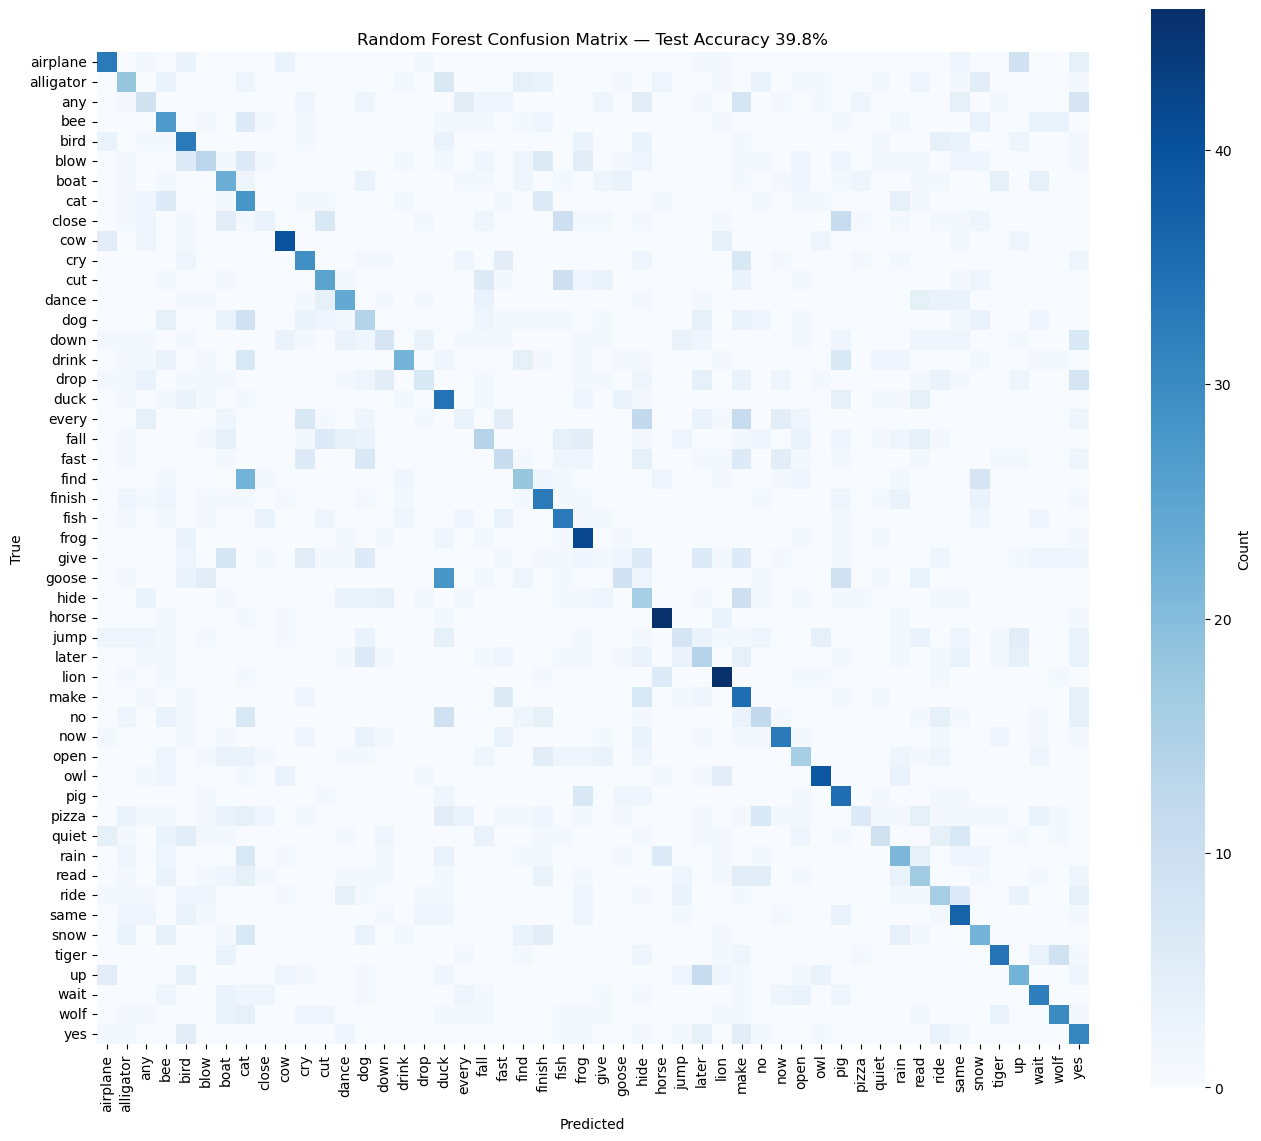


Top 10 confused pairs:
       goose -> duck         : 28 times
        find -> cat          : 22 times
       every -> hide         : 12 times
          up -> later        : 11 times
       close -> pig          : 11 times
       every -> make         : 11 times
       close -> fish         : 10 times
         cut -> fish         : 10 times
        hide -> make         : 10 times
          no -> duck         : 9 times


In [9]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, xticklabels=classes, yticklabels=classes, cmap='Blues', cbar_kws={'label': 'Count'}, square=True)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Random Forest Confusion Matrix — Test Accuracy {test_acc*100:.1f}%')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.savefig('rf_confusion_matrix.png', dpi=120)
plt.show()

# Top confused pairs
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
print('\nTop 10 confused pairs:')
flat_idx = np.argsort(cm_no_diag.ravel())[-10:][::-1]
for idx in flat_idx:
    i, j = np.unravel_index(idx, cm_no_diag.shape)
    if cm_no_diag[i, j] > 0:
        print(f'{classes[i]:>12} -> {classes[j]:<12} : {cm_no_diag[i, j]} times')

In [10]:

stat_groups = ['pos_mean', 'pos_std', 'pos_min', 'pos_max', 'pos_range',
               'pos_disp', 'vel_mean', 'vel_std', 'vel_absmax']
body_parts = {
    'dom_hand':     slice(0, 63),
    'non_dom_hand': slice(63, 126),
    'pose':         slice(126, 135),
    'presence':     slice(135, 137),
}

importances = final_rf.feature_importances_.reshape(len(stat_groups), N_POS)

# stat group
group_totals = importances.sum(axis=1)
plt.figure()
plt.bar(stat_groups, group_totals)
plt.ylabel('Total importance')
plt.title('Feature importance by stta group')
plt.xticks(rotation=30)
plt.savefig('rf_importance_by_stat.png', dpi=120)
plt.show()

# body part
part_totals = {name: importances[:, sl].sum() for name, sl in body_parts.items()}
plt.figure()
plt.bar(part_totals.keys(), part_totals.values())
plt.ylabel('Total importance')
plt.title('Feature importance by body part')
plt.savefig('rf_importance_by_bodypart.png', dpi=120)
plt.show()

# Heatmap: stat group × body part — tells you WHICH stats matter for WHICH parts
heatmap = np.zeros((len(stat_groups), len(body_parts)))
for i, o in enumerate(stat_groups):
    for j, (c, sl) in enumerate(body_parts.items()):
        heatmap[i, j] = importances[i, sl].sum()

plt.figure()
sns.heatmap(heatmap, xticklabels=list(body_parts.keys()), yticklabels=stat_groups, annot=True, fmt='.3f', cmap='viridis')
plt.title('Feature importance: stat group × body part')
plt.savefig('rf_importance_heatmap.png', dpi=120)
plt.show()

print(f'\nTotal importance by body part:')
for name, val in part_totals.items():
    print(f'  {name:<14}: {val:.4f}  ({val*100:.1f}%)')

NameError: name 'N_POS' is not defined